# 03 - Label Analysis

Compares the two independent spurious-halo label strategies:

- **`is_spurious_empirical`**: reproduces equation 4 of Mostoghiu Paun et al. (2025), a mass-dependent sphericity threshold.
- **`is_spurious_cdm_match`**: the primary ML label. A WDM halo has no CDM counterpart above the merit threshold in the matched simulation pair.

Here we adress the following questions: 
- Where do the labels agree? 
- Where do they disagree? 
- Is disagreement mass-dependent? 
- Are nulls concentrated at low mass?

## Setup

In [1]:
import warnings
import os
from pathlib import Path

project_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
os.chdir(project_root)

_latex = os.environ.get("LATEX_BIN_DIR")
if _latex:
    os.environ["PATH"] = _latex + ":" + os.environ["PATH"]

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import polars as pl

from src.config import load_config
from src.db import get_connection
from src.utils.plotting import apply_style

apply_style()

cfg = load_config()

FIGURES_DIR = Path("reports/figures")
from src.gold.features import FEATURE_COLS

## 1. Label counts

Counts per simulation for WDM haloes only, as CDM haloes receive null spurious labels. The underlying assumption is that CDM haloes cannot be spurious. 

While this is not necessarily always the case (see Power et al., 2016), CDM power spectra allow haloes to collapse at every scale. This makes identifying spurious haloes in CDM cosmologies tricky since there is no natural free-streaming scale to use as reference.

In [2]:
conn = get_connection(cfg.database_path, read_only=True)
label_counts = conn.execute("""
    SELECT
        f.simulation_id,
        f.cosmology,
        SUM(CASE WHEN l.is_spurious_cdm_match = true  THEN 1 ELSE 0 END) AS cdm_match_spurious,
        SUM(CASE WHEN l.is_spurious_cdm_match = false THEN 1 ELSE 0 END) AS cdm_match_genuine,
        SUM(CASE WHEN l.is_spurious_cdm_match IS NULL THEN 1 ELSE 0 END) AS cdm_match_null,
        SUM(CASE WHEN l.is_spurious_empirical = true  THEN 1 ELSE 0 END) AS empirical_spurious,
        SUM(CASE WHEN l.is_spurious_empirical = false THEN 1 ELSE 0 END) AS empirical_genuine,
        SUM(CASE WHEN l.is_spurious_empirical IS NULL THEN 1 ELSE 0 END) AS empirical_null
    FROM gold.features f
    LEFT JOIN gold.labels l
        ON f.halo_id = l.halo_id AND f.simulation_id = l.simulation_id
    WHERE f.cosmology = 'WDM'
    GROUP BY f.simulation_id, f.cosmology
    ORDER BY f.simulation_id
""").pl()
conn.close()
print(label_counts)

shape: (4, 8)
┌────────────┬───────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┐
│ simulation ┆ cosmology ┆ cdm_match_ ┆ cdm_match_ ┆ cdm_match ┆ empirical ┆ empirical ┆ empirical │
│ _id        ┆ ---       ┆ spurious   ┆ genuine    ┆ _null     ┆ _spurious ┆ _genuine  ┆ _null     │
│ ---        ┆ str       ┆ ---        ┆ ---        ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ str        ┆           ┆ decimal[38 ┆ decimal[38 ┆ decimal[3 ┆ decimal[3 ┆ decimal[3 ┆ decimal[3 │
│            ┆           ┆ ,0]        ┆ ,0]        ┆ 8,0]      ┆ 8,0]      ┆ 8,0]      ┆ 8,0]      │
╞════════════╪═══════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ wdm_512_z3 ┆ WDM       ┆ 15836      ┆ 3631       ┆ 0         ┆ 8009      ┆ 5051      ┆ 6407      │
│ 9_adapt    ┆           ┆            ┆            ┆           ┆           ┆           ┆           │
│ wdm_512_z3 ┆ WDM       ┆ 15334      ┆ 3245       ┆ 0         ┆ 5979      ┆ 

## 2. Label agreement

Contingency table of the two labels for WDM haloes where both are non-null. 

Nulls in `label_agreement` come from missing protohalo data (`has_protohalo_data = False`), not genuine label disagreement.

In [ ]:
conn = get_connection(cfg.database_path, read_only=True)
contingency = conn.execute("""
    SELECT
        is_spurious_empirical,
        is_spurious_cdm_match,
        COUNT(*) AS n
    FROM gold.labels
    WHERE is_spurious_empirical IS NOT NULL
      AND is_spurious_cdm_match IS NOT NULL
    GROUP BY is_spurious_empirical, is_spurious_cdm_match
    ORDER BY is_spurious_empirical, is_spurious_cdm_match
""").pl()
conn.close()

total = contingency["n"].sum()
contingency = contingency.with_columns(
    (pl.col("n") / total * 100).alias("percent")
)
print(contingency)

shape: (4, 4)
┌───────────────────────┬───────────────────────┬───────┬───────────┐
│ is_spurious_empirical ┆ is_spurious_cdm_match ┆ n     ┆ percent   │
│ ---                   ┆ ---                   ┆ ---   ┆ ---       │
│ bool                  ┆ bool                  ┆ i64   ┆ f64       │
╞═══════════════════════╪═══════════════════════╪═══════╪═══════════╡
│ false                 ┆ false                 ┆ 8841  ┆ 18.859191 │
│ false                 ┆ true                  ┆ 8887  ┆ 18.957316 │
│ true                  ┆ false                 ┆ 3528  ┆ 7.525758  │
│ true                  ┆ true                  ┆ 25623 ┆ 54.657736 │
└───────────────────────┴───────────────────────┴───────┴───────────┘


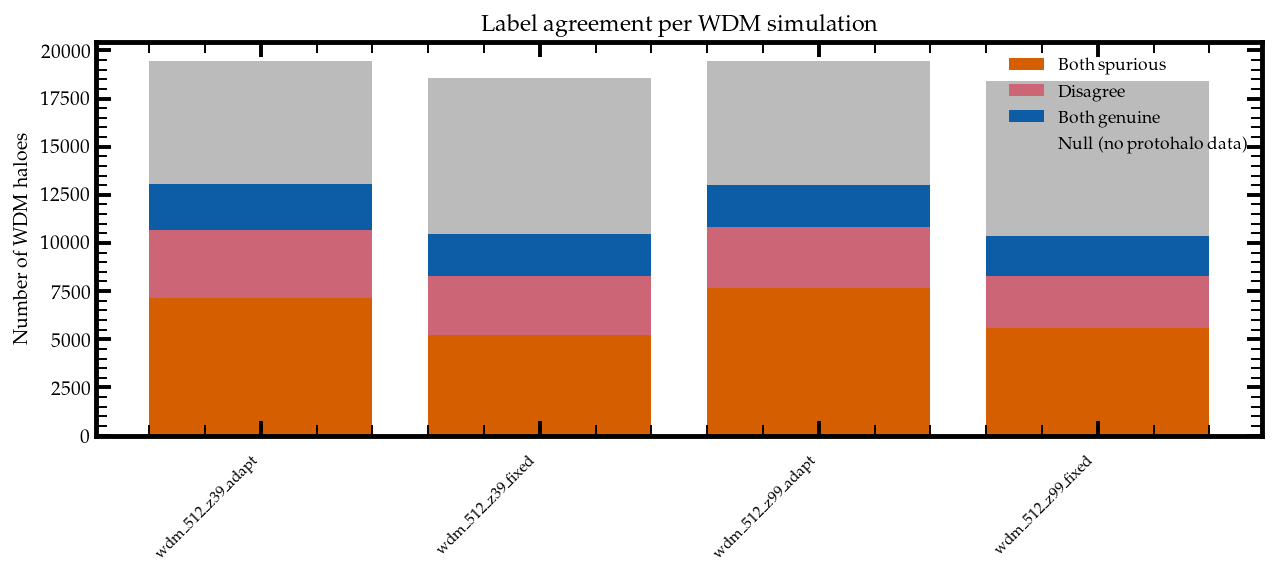

In [4]:
# Stacked bar: agree_spurious / disagree / agree_genuine / null (per simulation).
conn = get_connection(cfg.database_path, read_only=True)
agreement = conn.execute("""
    SELECT
        f.simulation_id,
        SUM(CASE WHEN l.label_agreement = true  AND l.is_spurious_cdm_match = true  THEN 1 ELSE 0 END) AS agree_spurious,
        SUM(CASE WHEN l.label_agreement = false THEN 1 ELSE 0 END) AS disagree,
        SUM(CASE WHEN l.label_agreement = true  AND l.is_spurious_cdm_match = false THEN 1 ELSE 0 END) AS agree_genuine,
        SUM(CASE WHEN l.label_agreement IS NULL THEN 1 ELSE 0 END) AS null_agreement
    FROM gold.labels l
    JOIN gold.features f
        ON l.halo_id = f.halo_id AND l.simulation_id = f.simulation_id
    WHERE f.cosmology = 'WDM'
      AND l.is_spurious_cdm_match IS NOT NULL
    GROUP BY f.simulation_id
    ORDER BY f.simulation_id
""").pl()
conn.close()

sim_ids       = agreement["simulation_id"].to_list()
ag_spur       = agreement["agree_spurious"].to_numpy()
disagree      = agreement["disagree"].to_numpy()
ag_gen        = agreement["agree_genuine"].to_numpy()
null_ag       = agreement["null_agreement"].to_numpy()
x             = np.arange(len(sim_ids))

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
_ = ax.bar(x, ag_spur,  color="#D55E00", label="Both spurious")
_ = ax.bar(x, disagree, bottom=ag_spur, color="#CC6677", label="Disagree")
_ = ax.bar(x, ag_gen,   bottom=ag_spur + disagree, color="#0C5DA5", label="Both genuine")
_ = ax.bar(x, null_ag,  bottom=ag_spur + disagree + ag_gen, color="#bbbbbb", label="Null (no protohalo data)")
_ = ax.set_xticks(x)
_ = ax.set_xticklabels(sim_ids, rotation=45, ha="right", fontsize=8)
_ = ax.set_ylabel("Number of WDM haloes")
_ = ax.set_title("Label agreement per WDM simulation")
_ = ax.legend(fontsize=9)
fig.savefig(FIGURES_DIR / "03_label_agreement.png", dpi=200, bbox_inches="tight")

## 3. Mass-dependence of disagreement

The empirical label is derived from a mean sphericity–mass relation. 

At low mass, where the spurious fraction is highest and the sphericity distributions overlap most, label disagreement is expected to peak.

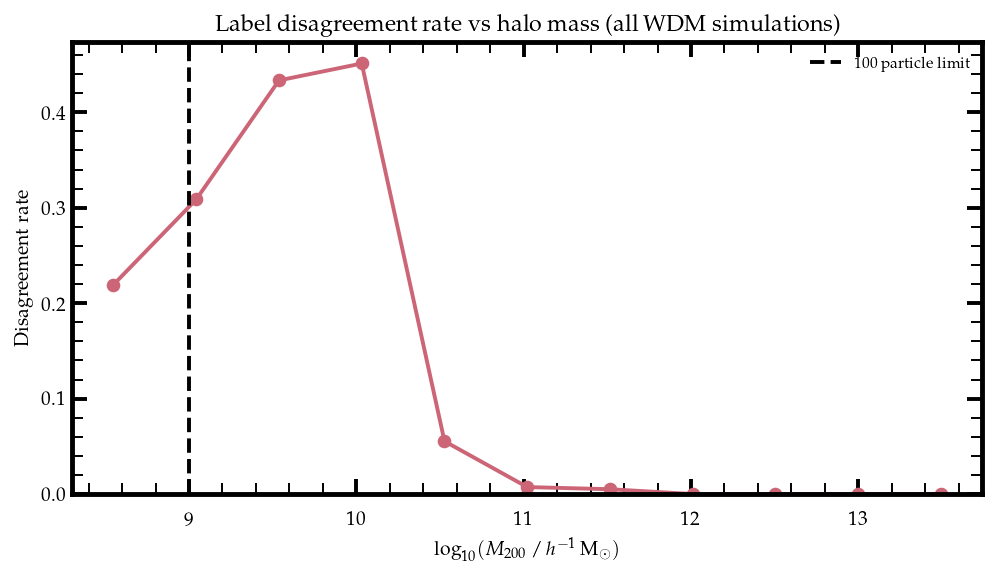

In [10]:
conn = get_connection(cfg.database_path, read_only=True)
mass_agree = conn.execute("""
    SELECT
        f.simulation_id,
        f.log10_m200,
        l.label_agreement,
        l.is_spurious_cdm_match
    FROM gold.labels l
    JOIN gold.features f
        ON l.halo_id = f.halo_id AND l.simulation_id = f.simulation_id
    WHERE f.cosmology = 'WDM'
      AND l.is_spurious_cdm_match IS NOT NULL
      AND l.is_spurious_empirical IS NOT NULL
""").pl()
conn.close()

# Disagreement rate per log10_m200 bin.
bins = np.linspace(
    float(mass_agree["log10_m200"].min()),
    float(mass_agree["log10_m200"].max()),
    12,
)
bin_centres = 0.5 * (bins[:-1] + bins[1:])
bin_labels  = np.digitize(mass_agree["log10_m200"].to_numpy(), bins) - 1
disagree_arr = (mass_agree["label_agreement"] == False).to_numpy()

rates = [
    disagree_arr[bin_labels == b].mean() if (bin_labels == b).sum() > 0 else np.nan
    for b in range(len(bin_centres))
]

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
_ = ax.plot(bin_centres, rates, color="#CC6677", marker="o", linewidth=2)
_ = ax.axvline(9, color="k", linestyle="--", label=r"100 particle limit")
_ = ax.set_xlabel(r"$\log_{10}(M_{200}\,/\,h^{-1}\,{\rm M}_\odot)$")
_ = ax.set_ylabel("Disagreement rate")
_ = ax.set_title("Label disagreement rate vs halo mass (all WDM simulations)")
_ = ax.set_ylim(0, None)
_ = ax.legend()

### Scatter: sphericity vs half-mode mass, coloured by agreement

Filled contours show the 68% and 95% density containment regions for the two agreeing populations. Points outside the 95% contour are drawn as individual markers. Disagreeing haloes are always plotted individually. 

The dashed line is: $\bar{s} = 0.0624 \cdot \log_{10}(M_{\rm hmm}\,/\,h^{-1}\,{\rm M}_\odot) - 0.0988$.

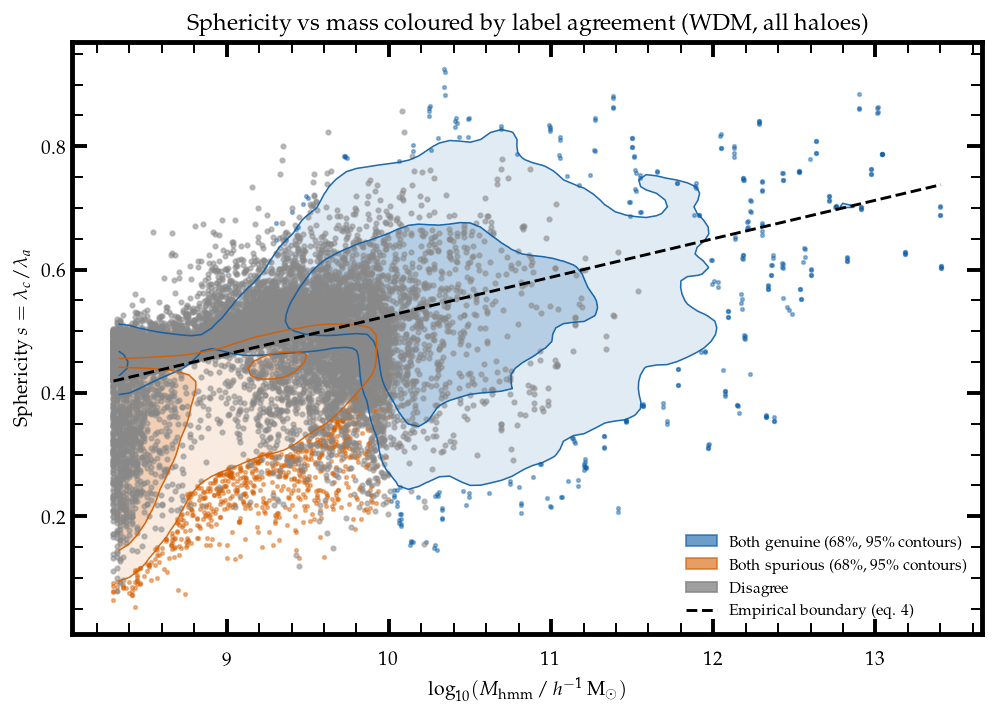

In [11]:
from scipy.ndimage import gaussian_filter
from matplotlib.lines import Line2D

conn = get_connection(cfg.database_path, read_only=True)
scatter_df = conn.execute("""
    SELECT
        f.log10_m_hmm,
        f.sphericity_s,
        l.label_agreement,
        l.is_spurious_cdm_match
    FROM gold.labels l
    JOIN gold.features f
        ON l.halo_id = f.halo_id AND l.simulation_id = f.simulation_id
    WHERE f.cosmology = 'WDM'
      AND f.sphericity_s IS NOT NULL
      AND f.log10_m_hmm IS NOT NULL
      AND l.label_agreement IS NOT NULL
""").pl()
conn.close()

agree_mask    = scatter_df["label_agreement"].to_numpy().astype(bool)
spurious_mask = scatter_df["is_spurious_cdm_match"].to_numpy().astype(bool)
x_all = scatter_df["log10_m_hmm"].to_numpy()
y_all = scatter_df["sphericity_s"].to_numpy()

x_lim = (float(x_all.min()), float(x_all.max()))
y_lim = (float(y_all.min()), float(y_all.max()))
BINS  = 80


def density_contours(
    x: np.ndarray,
    y: np.ndarray,
    ax: plt.Axes,
    color: str,
    sigma: float = 1.5,
) -> np.ndarray:
    """Draw 68 % and 95 % density contours; return a boolean outlier mask.

    Parameters
    ----------
    x, y : np.ndarray
        Coordinates of the point cloud.
    ax : plt.Axes
        Target axes.
    color : str
        Hex colour for fill and contour lines.
    sigma : float
        Gaussian smoothing width in histogram-bin units.

    Returns
    -------
    np.ndarray
        Boolean mask — ``True`` for points outside the 95 % contour.
    """
    h, xe, ye = np.histogram2d(x, y, bins=BINS, range=[x_lim, y_lim])
    h_smooth  = gaussian_filter(h, sigma=sigma)

    total    = h_smooth.sum()
    sorted_  = np.sort(h_smooth.ravel())[::-1]
    cumsum   = np.cumsum(sorted_)
    thresh68 = sorted_[np.searchsorted(cumsum, 0.68 * total)]
    thresh95 = sorted_[np.searchsorted(cumsum, 0.95 * total)]

    xc = 0.5 * (xe[:-1] + xe[1:])
    yc = 0.5 * (ye[:-1] + ye[1:])

    _ = ax.contourf(xc, yc, h_smooth.T,
                    levels=[thresh68, h_smooth.max()],
                    colors=[color], alpha=0.30)
    _ = ax.contourf(xc, yc, h_smooth.T,
                    levels=[thresh95, thresh68],
                    colors=[color], alpha=0.12)
    _ = ax.contour(xc, yc, h_smooth.T,
                   levels=[thresh95, thresh68],
                   colors=color, linewidths=0.8, alpha=0.9)

    xi = np.clip(np.digitize(x, xe) - 1, 0, BINS - 1)
    yi = np.clip(np.digitize(y, ye) - 1, 0, BINS - 1)
    return h_smooth[xi, yi] < thresh95


fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

# Agree genuine
mask_gen     = agree_mask & ~spurious_mask
x_gen, y_gen = x_all[mask_gen], y_all[mask_gen]
out_gen      = density_contours(x_gen, y_gen, ax, "#0C5DA5")
_ = ax.scatter(x_gen[out_gen], y_gen[out_gen],
               s=3, alpha=0.4, color="#0C5DA5", rasterized=True)

# Agree spurious
mask_spur      = agree_mask & spurious_mask
x_spur, y_spur = x_all[mask_spur], y_all[mask_spur]
out_spur       = density_contours(x_spur, y_spur, ax, "#D55E00")
_ = ax.scatter(x_spur[out_spur], y_spur[out_spur],
               s=3, alpha=0.4, color="#D55E00", rasterized=True)

# Disagree (always scatter)
mask_dis = ~agree_mask
_ = ax.scatter(x_all[mask_dis], y_all[mask_dis],
               s=5, alpha=0.5, color="#888888", rasterized=True)

# Empirical boundary: exact straight line in log10_m_hmm space
m_grid = np.linspace(*x_lim, 300)
_ = ax.plot(m_grid, 0.0624 * m_grid - 0.0988, "k--", linewidth=1.5)

# Legend via proxy artists
gen_patch  = mpatches.Patch(color="#0C5DA5", alpha=0.6,
                             label=r"Both genuine (68\%, 95\% contours)")
spur_patch = mpatches.Patch(color="#D55E00", alpha=0.6,
                             label=r"Both spurious (68\%, 95\% contours)")
dis_patch  = mpatches.Patch(color="#888888", alpha=0.8, label="Disagree")
bnd_line   = Line2D([0], [0], color="k", linestyle="--",
                    linewidth=1.5, label="Empirical boundary (eq. 4)")
_ = ax.legend(handles=[gen_patch, spur_patch, dis_patch, bnd_line], fontsize=8)

_ = ax.set_xlabel(r"$\log_{10}(M_{\rm hmm}\,/\,h^{-1}\,{\rm M}_\odot)$")
_ = ax.set_ylabel(r"Sphericity $s = \lambda_c / \lambda_a$")
_ = ax.set_title("Sphericity vs mass coloured by label agreement (WDM, all haloes)")
fig.savefig(FIGURES_DIR / "03_label_sphericity_scatter.png", dpi=200, bbox_inches="tight")

## 4. Null patterns

Null labels (`label_agreement IS NULL`) arise when protohalo data is missing. 

Small haloes are over-represented in the null set because AHF’s 10-snapshot survival criterion disproportionately filters low-mass haloes.

In [7]:
conn = get_connection(cfg.database_path, read_only=True)
null_by_mass = conn.execute("""
    SELECT
        f.simulation_id,
        FLOOR(f.log10_m200) AS log10_m_floor,
        SUM(CASE WHEN l.label_agreement IS NULL THEN 1 ELSE 0 END)     AS n_null,
        SUM(CASE WHEN l.label_agreement IS NOT NULL THEN 1 ELSE 0 END) AS n_non_null
    FROM gold.labels l
    JOIN gold.features f
        ON l.halo_id = f.halo_id AND l.simulation_id = f.simulation_id
    WHERE f.cosmology = 'WDM'
      AND l.is_spurious_cdm_match IS NOT NULL
    GROUP BY f.simulation_id, FLOOR(f.log10_m200)
    ORDER BY f.simulation_id, log10_m_floor
""").pl()
conn.close()

null_by_mass = null_by_mass.with_columns(
    (pl.col("n_null").cast(pl.Float64) / (pl.col("n_null") + pl.col("n_non_null"))).alias("null_frac")
)
print(null_by_mass)

shape: (24, 5)
┌───────────────────┬───────────────┬───────────────┬───────────────┬───────────┐
│ simulation_id     ┆ log10_m_floor ┆ n_null        ┆ n_non_null    ┆ null_frac │
│ ---               ┆ ---           ┆ ---           ┆ ---           ┆ ---       │
│ str               ┆ f64           ┆ decimal[38,0] ┆ decimal[38,0] ┆ f64       │
╞═══════════════════╪═══════════════╪═══════════════╪═══════════════╪═══════════╡
│ wdm_512_z39_adapt ┆ 8.0           ┆ 5429          ┆ 7241          ┆ 0.428493  │
│ wdm_512_z39_adapt ┆ 9.0           ┆ 825           ┆ 3433          ┆ 0.193753  │
│ wdm_512_z39_adapt ┆ 10.0          ┆ 130           ┆ 1892          ┆ 0.064293  │
│ wdm_512_z39_adapt ┆ 11.0          ┆ 18            ┆ 425           ┆ 0.040632  │
│ wdm_512_z39_adapt ┆ 12.0          ┆ 4             ┆ 60            ┆ 0.0625    │
│ …                 ┆ …             ┆ …             ┆ …             ┆ …         │
│ wdm_512_z99_fixed ┆ 9.0           ┆ 669           ┆ 2823          ┆ 0.191581  │
│